In [67]:
%matplotlib inline
import mdtraj as md
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib
from contact_map import ContactFrequency, ContactDifference, AtomMismatchedContactDifference
import scipy.stats as st
from scipy.stats import ttest_ind
from tqdm.notebook import tqdm

In [3]:
minA = 1
maxA = 58
minB = 60
maxB = 72
traj_combined_list = []

# AbpSH3 ArkA12 No salt Encounter

In [4]:
traj_no_salt_list = ["encounter_complex_nosalt_sim1-stripped.mdcrd", "encounter_complex_nosalt_sim2-stripped.mdcrd", "encounter_complex_nosalt_sim3-stripped.mdcrd", "encounter_complex_nosalt_sim4-stripped.mdcrd", "encounter_complex_nosalt_sim5-stripped.mdcrd", "encounter_complex_nosalt_sim6-stripped.mdcrd", "encounter_complex_nosalt_sim7-stripped.mdcrd", "encounter_complex_nosalt_sim8-stripped.mdcrd", "encounter_complex_nosalt_sim9-stripped.mdcrd", "encounter_complex_nosalt_sim10-stripped.mdcrd"]

traj_no_salt_new = []
for suffix in traj_no_salt_list:
    traj_no_salt_new.append(md.load_netcdf("/data/amujica/ArkA12_binding/nosalt_filtered/stripped/" + suffix, 
                          top="/data/rcarrock/ArkA_binding_cont/analysis_all/ArkA12_1_gas.prmtop", 
                                   stride=300))

In [5]:
traj_no_salt_new[0]

<mdtraj.Trajectory with 1514 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f83d2f60>

In [36]:
topology = traj_no_salt_new[0].topology
topology

<mdtraj.Topology with 1 chains, 72 residues, 1098 atoms, 1116 bonds at 0x1553f84eac90>

In [7]:
traj_no_salt_new

[<mdtraj.Trajectory with 1514 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f83d2f60>,
 <mdtraj.Trajectory with 1560 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f8508200>,
 <mdtraj.Trajectory with 1549 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f818f020>,
 <mdtraj.Trajectory with 1556 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f83fbe00>,
 <mdtraj.Trajectory with 1466 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f83d2ab0>,
 <mdtraj.Trajectory with 1494 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f83bb500>,
 <mdtraj.Trajectory with 1509 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f7d2fdd0>,
 <mdtraj.Trajectory with 1533 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f83bb290>,
 <mdtraj.Trajectory with 1471 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f7d2fe00>,
 <mdtraj.Trajectory with 1532 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f

In [8]:
import sys
sys.getsizeof(traj_no_salt_new.copy())

136

In [9]:
traj_no_salt_combined = md.join(traj_no_salt_new)

In [10]:
# cat /proc/sys/vm/overcommit_memory

In [11]:
traj_no_salt_combined

<mdtraj.Trajectory with 15184 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f7aa4e00>

In [12]:
traj_no_salt_combined_contacts = ContactFrequency(traj_no_salt_combined)

Current dimensions: 20.0 x 4.0 inches
New dimensions: 7 x 1.4000000000000001 inches


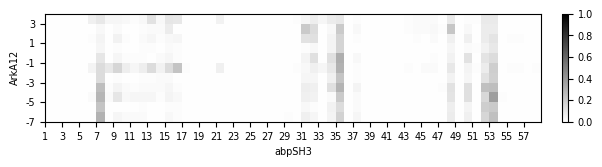

CPU times: user 2.37 s, sys: 15 ms, total: 2.38 s
Wall time: 2.39 s


In [13]:
%%time
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["black","white","black"])
fig, ax = traj_no_salt_combined_contacts.residue_contacts.plot (figsize=(20, 4), cmap=cmap)
cb_ax = fig.axes[1]
cb_ax.tick_params(labelsize=7)
my_xticks = []
current_xticks = []

for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)

# --- Y-Axis Relabeling ---
my_yticks = ['-7', '-5', '-3', '-1', '1', '3']
# This creates positions [60. , 62. , 64. , 66. , 68. , 70.]
current_yticks = np.linspace(60, 70, len(my_yticks))

ax.set_yticks(current_yticks)
ax.set_yticklabels(my_yticks, fontsize=7)
ax.set_ylim(60, 71)
ax.set_xlim(0,58)

# -------------------------
    
plt.xticks(current_xticks, my_xticks, fontsize = 7)
#ax.set_yticklabels(my_yticks)
plt.yticks(current_yticks, my_yticks, fontsize = 7)
plt.xlabel("abpSH3", fontsize=7)
plt.ylabel("ArkA12", fontsize=7)
#plt.title('ArkA12_bound_contact_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_phosphorylated.png', bbox_inches = "tight", dpi= 2000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('contact_no_salt.png', dpi=1000, bbox_inches='tight')

plt.show()

In [14]:
type(traj_no_salt_combined_contacts.residue_contacts)

contact_map.contact_count.ContactCount

# AbpSH3 ArkA12 Salt Encounter 

In [15]:
traj_salt_list = [
    "/cluster_0/cluster_0_allsim.mdcrd",
    "/cluster_1/cluster_1_allsim.mdcrd",
    "/cluster_2/cluster_2_allsim.mdcrd",
    "/cluster_3/cluster_3_allsim.mdcrd",
    "/cluster_4/cluster_4_allsim.mdcrd",]

prmtop_list = [
    "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl/cluster_0/ArkA12_0_gas_ions.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl/cluster_1/ArkA12_1_gas_ions.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl/cluster_2/ArkA12_2_gas_ions.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl/cluster_3/ArkA12_3_gas_ions.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl/cluster_4/ArkA12_4_gas_ions.prmtop",
]

traj_salt_new = []
for traj_path, top_path in zip(traj_salt_list, prmtop_list):
    full_traj_path = "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl" + traj_path
    traj_salt_new.append(
        md.load_netcdf(full_traj_path, top=top_path, stride=100) # the stride should be some multiple of 10
    )


In [16]:
traj_salt_new

[<mdtraj.Trajectory with 10000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553f0f98440>,
 <mdtraj.Trajectory with 10000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553e679f260>,
 <mdtraj.Trajectory with 10000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553e6768470>,
 <mdtraj.Trajectory with 10000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553e67aaf00>,
 <mdtraj.Trajectory with 10000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553f0c0bf50>]

## Add code to use only encounter frames

In [17]:
arka12_stat = pd.read_csv('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/status_files/ArkA12_binding_salt_status.csv')
arka12_stat = arka12_stat.iloc[99::100, :]

In [18]:
arka12_stat

,Unnamed: 0,#Frame,status
99,99,100,unbound
199,199,200,unbound
299,299,300,unbound
399,399,400,unbound
499,499,500,unbound
...,...,...,...
4999599,4999599,4999600,partial
4999699,4999699,4999700,partial
4999799,4999799,4999800,partial
4999899,4999899,4999900,partial


In [19]:
arka12_stat[(arka12_stat['status'] != 'unbound') & (arka12_stat['status'] != 'Bound')]

,Unnamed: 0,#Frame,status
4199,4199,4200,partial
4299,4299,4300,partial
4399,4399,4400,partial
4499,4499,4500,partial
4599,4599,4600,partial
...,...,...,...
4999599,4999599,4999600,partial
4999699,4999699,4999700,partial
4999799,4999799,4999800,partial
4999899,4999899,4999900,partial


In [20]:
tot_frames = len(arka12_stat)
num_clusters = 5
traj_salt_encounter = []

for i in range(num_clusters):
    arka12_stat_cluster = arka12_stat[int(tot_frames*(i/num_clusters)):int(tot_frames*((i+1)/num_clusters))]
    traj_salt_encounter.append(traj_salt_new[i][(arka12_stat_cluster['status'] != 'unbound') & (arka12_stat_cluster['status'] != 'Bound')])

In [21]:
traj_salt_encounter

[<mdtraj.Trajectory with 6072 frames, 1475 atoms, 449 residues, without unitcells at 0x1553f08ebec0>,
 <mdtraj.Trajectory with 5239 frames, 1475 atoms, 449 residues, without unitcells at 0x1553f0b6b620>,
 <mdtraj.Trajectory with 6733 frames, 1475 atoms, 449 residues, without unitcells at 0x1553f084ccb0>,
 <mdtraj.Trajectory with 7592 frames, 1475 atoms, 449 residues, without unitcells at 0x1553e67df3e0>,
 <mdtraj.Trajectory with 6202 frames, 1475 atoms, 449 residues, without unitcells at 0x1553f0a0e240>]

In [22]:
topology = md.join(traj_salt_new).topology
df = topology.to_dataframe()[0]
topology = md.Topology.from_dataframe(df[(df['element'] != 'Na')][(df['element'] != 'Cl')])

/tmp/ipykernel_580729/7110114.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  topology = md.Topology.from_dataframe(df[(df['element'] != 'Na')][(df['element'] != 'Cl')])


In [23]:
traj_combined_salt = md.join(traj_salt_encounter)

In [24]:
traj_combined_contacts_salt = ContactFrequency(traj_combined_salt)

In [25]:
def get_window(diffy):
    window = pd.DataFrame(diffy.residue_contacts.df.iloc[:72, :72]).fillna(0).iloc[60:72, 0:58]
    return window.reindex(index=window.index[::-1])

In [26]:
diffy_salt = []
diffy_no_salt = []
for i in tqdm(range(min(len(traj_salt_encounter), len(traj_no_salt_new)))):
    #diffy.append(AtomMismatchedContactDifference(salt_con, no_salt_con))
    diffy_salt.append(ContactFrequency(traj_salt_encounter[i]))
    diffy_no_salt.append(ContactFrequency(traj_no_salt_new[i]))

  0%|          | 0/5 [00:00<?, ?it/s]

In [27]:
def ci_intersect(bs1, bs2):
    high1 = bs1.confidence_interval.high
    high2 = bs1.confidence_interval.high
    low1 = bs2.confidence_interval.low
    low2 = bs2.confidence_interval.low
    
    if low1 < low2:
        return high1 < low2
    else:
        return high2 < low1

In [28]:
def bootstrap(data1, data2, numsample=int(1e5)):
    len_1 = len(data1)
    len_2 = len(data2)
    
    data = np.concatenate([data1, data2])

    diff = abs(np.mean(data[:len_2]) - np.mean(data[len_1:]))
    
    diff_samples = np.zeros(numsample)
    diff_samples_larger = 0

    for sample in range(len(diff_samples)):
        random_groups = np.random.permutation(data)
        
        diff_samples[sample] = np.mean(random_groups[:len_2]) - np.mean(random_groups[len_1:])
        
        if diff_samples[sample] >= diff:
            diff_samples_larger += 1

    return (1 + diff_samples_larger) / (numsample + 1)

In [29]:
import scipy.stats

diff_df_salt = [get_window(diff) for diff in diffy_salt]
diff_df_no_salt = [get_window(diff) for diff in diffy_no_salt]
significant = diff_df_salt[0].copy().sparse.to_dense()

# p_val_df = diff_df_no_salt[0].copy(deep=True)
p_val_df = pd.DataFrame().reindex_like(diff_df_no_salt[0])

for col in tqdm(range(len(diff_df_salt[0].columns))):
    for row in range(len(diff_df_salt[0].index)):
        salt_data = [df.iloc[row, col] for df in diff_df_salt]
#         print(f"salty daty: ",row, col)
        no_salt_data = [df.iloc[row, col] for df in diff_df_no_salt]
        if all(v == 0 for v in no_salt_data) and all(v == 0 for v in salt_data):
            significant.iloc[row, col] = 1
        else:
            pval = bootstrap(salt_data, no_salt_data)
            significant.iloc[row, col] = pval
# p_val_df

  0%|          | 0/58 [00:00<?, ?it/s]

In [30]:
significant

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
71,0.501195,0.223648,1.000000,0.221838,0.498255,0.090499,0.398356,0.135489,0.437716,0.195218,...,1.000000,0.472365,0.428076,0.363626,0.072159,0.058999,0.043310,0.136149,0.161018,0.242808
70,0.500055,0.222368,1.000000,0.170788,0.142909,0.331097,0.339767,0.144859,0.080899,0.063119,...,1.000000,0.400446,0.486505,0.496115,0.291207,0.006470,0.088259,0.122589,0.500385,0.448626
69,0.003890,0.502845,1.000000,0.361006,0.499955,0.134259,0.009110,0.067059,0.074909,0.414776,...,0.499115,0.100119,0.144849,0.090609,0.220288,0.242298,0.052789,0.007520,0.224048,0.288717
68,0.082019,0.499655,0.498245,0.498245,1.000000,0.087339,0.038720,0.445146,0.052059,0.187988,...,0.502145,0.162468,0.230718,0.137729,0.186898,0.051059,0.293247,0.416976,0.360936,0.264447
67,0.221258,0.501135,0.498155,0.085079,0.500725,0.246718,0.031470,0.003860,0.048290,0.046700,...,1.000000,0.122589,0.497425,0.360976,0.061989,0.021250,0.502715,0.418966,0.221748,0.403106
66,0.501335,0.359146,1.000000,0.498645,1.000000,0.086599,0.149379,0.070659,0.154238,0.363336,...,0.498175,0.064059,0.171278,0.402266,0.468725,0.018520,0.228728,0.194988,0.438806,0.383506
65,0.223888,0.498555,1.000000,0.439786,0.497805,0.193368,0.243088,0.047560,0.090729,0.003810,...,1.000000,0.061809,0.199058,0.101949,0.234728,0.055159,0.108709,0.121459,0.501855,0.424166
64,0.027490,0.498805,1.000000,1.000000,1.000000,0.118009,0.174538,0.028620,0.059859,0.007980,...,1.000000,0.495695,0.019840,0.146959,0.298387,0.238788,0.102989,0.023370,0.258057,0.358436
63,0.007770,0.222928,1.000000,1.000000,1.000000,0.163408,0.144649,0.486765,0.142099,0.392146,...,0.502315,0.345217,0.208688,0.139209,0.016420,0.223498,0.142999,0.020290,0.143469,0.478075
62,0.364376,0.497365,1.000000,1.000000,0.499735,0.431656,0.065649,0.129459,0.099659,0.396506,...,0.497415,0.123339,0.120629,0.191928,0.006310,0.360836,0.159318,0.043360,0.262877,0.264157


In [32]:
significant[significant < 0.05]

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.04331,NaN,NaN,NaN
70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.00647,NaN,NaN,NaN,NaN
69,0.00389,NaN,NaN,NaN,NaN,NaN,0.00911,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00752,NaN,NaN
68,NaN,NaN,NaN,NaN,NaN,NaN,0.03872,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN,NaN,0.03147,0.00386,0.04829,0.04670,...,NaN,NaN,NaN,NaN,NaN,0.02125,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.01852,NaN,NaN,NaN,NaN
65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04756,NaN,0.00381,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,0.02749,NaN,NaN,NaN,NaN,NaN,NaN,0.02862,NaN,0.00798,...,NaN,NaN,0.01984,NaN,NaN,NaN,NaN,0.02337,NaN,NaN
63,0.00777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.01642,NaN,NaN,0.02029,NaN,NaN
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.00631,NaN,NaN,0.04336,NaN,NaN


In [33]:

print(significant.iloc[:15,8 ])  # Display all available rows of column ten since there are only 9 rows

71    0.437716
70    0.080899
69    0.074909
68    0.052059
67    0.048290
66    0.154238
65    0.090729
64    0.059859
63    0.142099
62    0.099659
61    0.020030
60    0.317327
Name: 8, dtype: float64


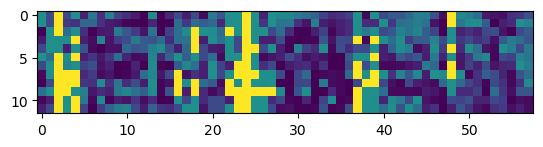

In [34]:
plt.imshow(np.array(significant.values.tolist()))

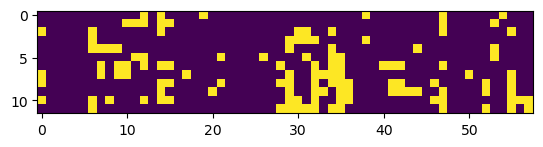

In [35]:
plt.imshow(np.array((significant < 0.05).values.tolist()))

In [35]:
np.where(significant < 0.05)

(array([ 0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,
         2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,
         4,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
         6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,
         7,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  9,
         9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10,
        10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11,
        11, 11, 11, 11, 11, 11, 11]),
 array([12, 14, 19, 38, 47, 54, 10, 11, 12, 14, 15, 47, 53,  0,  6, 14, 30,
        31, 34, 47, 55,  6, 29, 30, 31, 32, 38,  6,  7,  8,  9, 29, 34, 44,
        53, 11, 12, 21, 26, 31, 34, 35, 53,  7,  9, 10, 12, 14, 15, 28, 32,
        34, 35, 40, 41, 42, 47,  0,  7,  9, 10, 17, 29, 32, 33, 34, 35, 50,
        55,  0, 14, 15, 21, 28, 29, 32, 34, 35, 36, 41, 42, 46, 52, 55, 14,
        20, 29, 32, 33, 35, 36, 41, 42, 43, 44, 47

In [36]:
print(no_salt_data)

[0.0006605019815059445, 0.000641025641025641, 0, 0, 0]


In [37]:
p_val_df[(p_val_df < 0.05)]
#list(zip(list(np.argwhere(p_val_df.to_numpy())), list(np.where(p_val_df.to_numpy()))))

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/home/mcohen3/.local/lib/python3.12/site-packages/contact_map/contact_count.py:176: RuntimeWarning: The number of pixels in the figure is insufficient to show all the contacts.
 Please save this as a vector image (such as a PDF) to view the correct result.
 Another option is to increase the 'dpi' (currently: 100.0), or the 'figsize' (currently: (20.0, 4.0)).
 Recommended minimum amount of pixels = (449, 449) (width, height).
  warnings.warn(msg, RuntimeWarning)


Current dimensions: 20.0 x 4.0 inches
New dimensions: 7 x 1.4000000000000001 inches


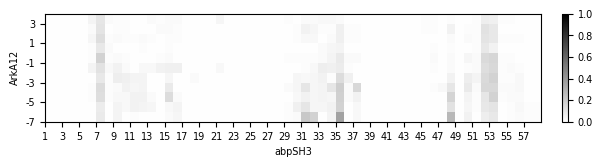

CPU times: user 2min 38s, sys: 2.11 s, total: 2min 40s
Wall time: 2min 41s


In [44]:
%%time
fig, ax = traj_combined_contacts_salt.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap= cmap)
cb_ax = fig.axes[1]
cb_ax.tick_params(labelsize=7)

my_xticks = []
current_xticks = []

for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
# --- Y-Axis Relabeling ---
my_yticks = ['-7', '-5', '-3', '-1', '1', '3']
# This creates positions [60. , 62. , 64. , 66. , 68. , 70.]
current_yticks = np.linspace(60, 70, len(my_yticks))

ax.set_yticks(current_yticks)
ax.set_yticklabels(my_yticks, fontsize=7)
ax.set_ylim(60, 71)
ax.set_xlim(0,58)

# -------------------------
    
plt.xticks(current_xticks, my_xticks, fontsize = 7)
#ax.set_yticklabels(my_yticks)
plt.yticks(current_yticks, my_yticks, fontsize = 7)
plt.xlabel("abpSH3", fontsize=7)
plt.ylabel("ArkA12", fontsize=7)
#plt.title('ArkA12_bound_contact_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_phosphorylated.png', bbox_inches = "tight", dpi= 2000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('contact_salt.png', dpi=1000, bbox_inches='tight')

plt.show()

# ArkA12_Encounter_Contact_Difference

In [43]:
diff = AtomMismatchedContactDifference(traj_no_salt_combined_contacts, traj_combined_contacts_salt)

/home/mcohen3/.local/lib/python3.12/site-packages/contact_map/contact_count.py:176: RuntimeWarning: The number of pixels in the figure is insufficient to show all the contacts.
 Please save this as a vector image (such as a PDF) to view the correct result.
 Another option is to increase the 'dpi' (currently: 100.0), or the 'figsize' (currently: (20.0, 4.0)).
 Recommended minimum amount of pixels = (449, 449) (width, height).
  warnings.warn(msg, RuntimeWarning)


Current dimensions: 20.0 x 4.0 inches
New dimensions: 7 x 1.4000000000000001 inches


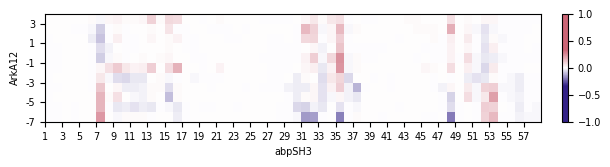

CPU times: user 2.34 s, sys: 17 ms, total: 2.36 s
Wall time: 2.36 s


In [48]:
%%time
map_1 = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#332288","#332288","#332288","white","#CC6677","#CC6677","#CC6677"])
fig, ax = diff.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap = map_1)
cb_ax = fig.axes[1]
cb_ax.tick_params(labelsize=7)
#plt.imshow(np.array((significant < 0.05).values.tolist()))
#PRGn is a matplot lib diverging colormap, using _r appendix on it to reverse if needed
my_xticks = []
current_xticks = []


for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
# --- Y-Axis Relabeling ---
my_yticks = ['-7', '-5', '-3', '-1', '1', '3']
# This creates positions [60. , 62. , 64. , 66. , 68. , 70.]
current_yticks = np.linspace(60, 70, len(my_yticks))

ax.set_yticks(current_yticks)
ax.set_yticklabels(my_yticks, fontsize=7)
ax.set_ylim(60, 71)
ax.set_xlim(0,58)

# -------------------------
    
plt.xticks(current_xticks, my_xticks, fontsize = 7)
#ax.set_yticklabels(my_yticks)
plt.yticks(current_yticks, my_yticks, fontsize = 7)
plt.xlabel("abpSH3", fontsize=7)
plt.ylabel("ArkA12", fontsize=7)
#plt.title('ArkA12_bound_contact_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_phosphorylated.png', bbox_inches = "tight", dpi= 2000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('contact_diff.png', dpi=1000, bbox_inches='tight')

plt.show()

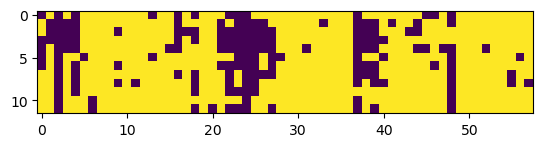

In [83]:
#np.array((significant[significant < 0.05]).values.tolist())
#ax.set_ylim(60, 71)
#ax.set_xlim(0,58)
salt = traj_combined_contacts_salt.residue_contacts.df.iloc[60:72,0:58]
no_salt = traj_no_salt_combined_contacts.residue_contacts.df.iloc[60:72,0:58]
difference = diff.residue_contacts.df.iloc[60:72,0:58]

perc_diff = ((difference.abs())/((salt + no_salt)/2))*100
plt.imshow(np.array((perc_diff > 10).values.tolist()))

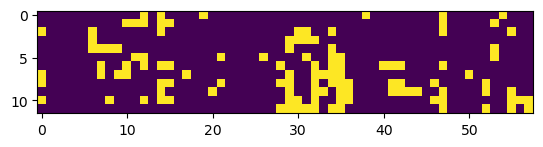

In [88]:
plt.imshow(np.array((significant < 0.05).values.tolist()) & np.array((perc_diff > 10).values.tolist()))

Current dimensions: 6.4 x 4.8 inches
New dimensions: 7 x 5.249999999999999 inches


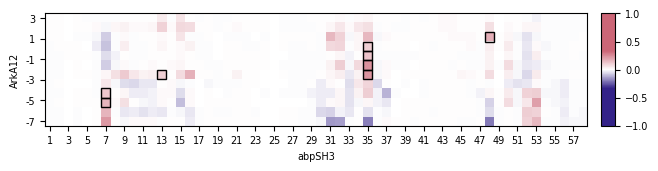

In [133]:
sig_and_10 = np.array((significant < 0.05).values.tolist()) & np.array((perc_diff > 10).values.tolist()) & np.array((difference > 0.1).values.tolist())

coords = np.argwhere(sig_and_10)

map_1 = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#332288","#332288","#332288","white","#CC6677","#CC6677","#CC6677"])
#fig, ax = difference.residue_contacts.plot(cmap = map_1)

fig, ax = plt.subplots()
im = plt.imshow(difference, cmap = map_1, vmin = -1, vmax = 1)
# 1. Get the current position of the plot in the figure
pos = ax.get_position()

# --- MISSING PIECE START ---
# Define the colorbar axes [left, bottom, width, height]
# pos.x1 + 0.02 puts it just to the right of the plot
# pos.y0 and pos.height ensure the vertical size matches exactly
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
# --- MISSING PIECE END ---

# Now this will work
cb = fig.colorbar(im, cax=cax)
cax.tick_params(labelsize=7)

# 2. Extract coordinates where mask is True
# Note: np.argwhere returns (row, col), but patches use (x, y) which is (col, row)

for row, col in coords:
    # Create a Rectangle patch
    # (col - 0.5, row - 0.5) aligns the box edges with the pixel edges
    rect = patches.Rectangle((col - 0.5, row - 0.5), 1, 1, 
                             linewidth=1, edgecolor='black', facecolor='none')
    ax.add_patch(rect)

#cb_ax = fig.axes[0]
#cb_ax.tick_params(labelsize=7)
#plt.imshow(np.array((significant < 0.05).values.tolist()))
#PRGn is a matplot lib diverging colormap, using _r appendix on it to reverse if needed
my_xticks = []
current_xticks = []


for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
# --- Y-Axis Relabeling ---
my_yticks = ['-7', '-5', '-3', '-1', '1', '3']
# This creates positions [60. , 62. , 64. , 66. , 68. , 70.]
current_yticks = np.linspace(0, 11, len(my_yticks))

ax.set_xlabel("abpSH3", fontsize = 7)
ax.set_ylabel("ArkA12", fontsize = 7)

my_xticks = []
current_xticks = []

# Loop through every single number in the range
for x in range(int(minA), int(maxA) + 1):
    # Check if the residue number is odd
    if x % 2 != 0:
        current_xticks.append(x - int(minA)) # The pixel position
        my_xticks.append(x)                  # The actual label

# Apply to the plot
ax.set_xticks(current_xticks)
ax.set_xticklabels(my_xticks, fontsize=7)
ax.set_yticks(current_yticks)
ax.set_yticklabels(my_yticks, fontsize=7)
ax.invert_yaxis()
#ax.set_ylim(60, 71)
#ax.set_xlim(0,58)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('contact_diff.png', dpi=1000, bbox_inches='tight')

plt.show()